In [1]:
import anndata as ad
import numpy as np
import pandas as pd
import SDP_miRNA.dataset
import SDP_miRNA.optimization
import SDP_miRNA.optimization_MOSEK
import SDP_miRNA.correlation
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import scanpy as sc

In [2]:
rng = np.random.default_rng(423)

In [3]:
# load pcRNA
adata_pcRNA = ad.read_h5ad("../HEK293T/TotalX_HEK293T_pcRNA.h5ad")

# load miRNA
adata_miRNA = ad.read_h5ad("../HEK293T/TotalX_HEK293T_miRNA.h5ad")

# load capture
beta = np.loadtxt("../HEK293T/TotalX_HEK293T_capture.txt")

In [44]:
# load results
ind_MF_df = pd.read_csv("../HEK293T/Results/New/independent_MF.csv", index_col=0)
int_MF_df = pd.read_csv("../HEK293T/Results/New/interacting_MF.csv", index_col=0)
corr_df = pd.read_csv("../HEK293T/Results/New/correlation.csv", index_col=0)

## Cell cycle scoring

In [4]:
adata_cc = adata_pcRNA.copy()
adata_cc.var_names = adata_cc.var['GeneName'].values.tolist()
adata_cc

AnnData object with n_obs × n_vars = 11945 × 10307
    var: 'gene_ids', 'feature_types', 'genome', 'GeneName', 'gene_id', 'biotype'
    layers: None (.X)

In [5]:
# load cell cycle genes
cell_cycle_genes = [x.strip() for x in open("../../Latent-Experiments/R-Notebooks/regev_lab_cell_cycle_genes.txt")]

# Split into 2 lists
s_genes = cell_cycle_genes[:43]
g2m_genes = cell_cycle_genes[43:]

# subset to observed
s_genes_data = [x for x in s_genes if x in adata_cc.var_names]
g2m_genes_data = [x for x in g2m_genes if x in adata_cc.var_names]
cell_cycle_genes_data = [x for x in cell_cycle_genes if x in adata_cc.var_names]


print(f"{len(s_genes_data)} / {len(s_genes)}")
print(f"{len(g2m_genes_data)} / {len(g2m_genes)}")

42 / 43
52 / 54


In [6]:
# normalize and log transform
sc.pp.normalize_total(adata_cc, target_sum=1e4)
sc.pp.log1p(adata_cc)

In [7]:
sc.tl.score_genes_cell_cycle(adata_cc, s_genes=s_genes_data, g2m_genes=g2m_genes_data)

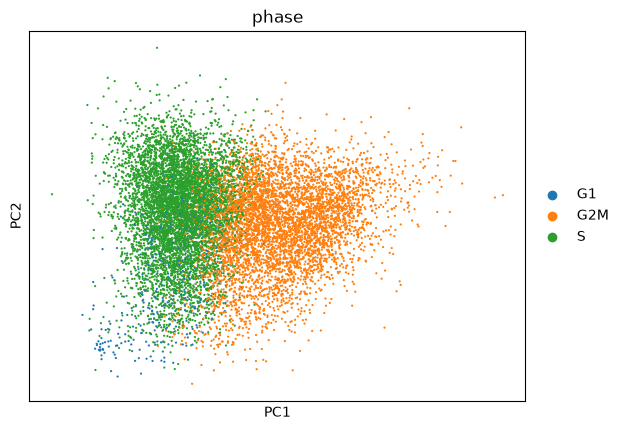

In [8]:
adata_cc_genes = adata_cc[:, cell_cycle_genes_data].copy()
sc.tl.pca(adata_cc_genes)
sc.pl.pca(adata_cc_genes, color="phase")

In [9]:
adata_cc.obs['phase'].value_counts()

phase
S      6285
G2M    5217
G1      443
Name: count, dtype: int64

In [13]:
# split capture by phase
beta_G1 = beta[adata_cc.obs['phase'] == "G1"]
beta_S = beta[adata_cc.obs['phase'] == "S"]
beta_G2M = beta[adata_cc.obs['phase'] == "G2M"]

## Inference

In [10]:
# choose miRNA
miRNA = "MIR4709"

# choose mRNA: negatively correlated using all cells
names_neg = np.array(['MIR4709', 'LRBA', 'PWWP2A', 'IMMP2L', 'WDR76', 'ZNF557'])

# number of targets
T = len(names_neg)

In [11]:
# subset adata
adata_neg = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_neg)]
adata_miRNA_chosen = adata_miRNA[:, adata_miRNA.var['GeneName'] == miRNA]

# combine 
adata_chosen = ad.concat([adata_miRNA_chosen, adata_neg], axis=1)

In [12]:
# split cells by phase
adata_chosen_G1 = adata_chosen[adata_cc.obs['phase'] == "G1", :]
adata_chosen_S = adata_chosen[adata_cc.obs['phase'] == "S", :]
adata_chosen_G2M = adata_chosen[adata_cc.obs['phase'] == "G2M", :]

In [14]:
# select all gene pairs: no repeats
Is, Js = np.triu_indices(T, k=1)
gene_queries = [
    [[int(i)], [int(j)]] for i, j in zip(Is, Js)
]

# construct dataset
SDP_data = SDP_miRNA.dataset.Dataset()
SDP_data_G1 = SDP_miRNA.dataset.Dataset()
SDP_data_S = SDP_miRNA.dataset.Dataset()
SDP_data_G2M = SDP_miRNA.dataset.Dataset()
SDP_data.construct_dataset_adata(adata_chosen, adata_chosen, beta, gene_queries)
SDP_data_G1.construct_dataset_adata(adata_chosen_G1, adata_chosen_G1, beta_G1, gene_queries)
SDP_data_S.construct_dataset_adata(adata_chosen_S, adata_chosen_S, beta_S, gene_queries)
SDP_data_G2M.construct_dataset_adata(adata_chosen_G2M, adata_chosen_G2M, beta_G2M, gene_queries)

# bootstrap
SDP_data.bootstrap(d=3)
SDP_data_G1.bootstrap(d=3)
SDP_data_S.bootstrap(d=3)
SDP_data_G2M.bootstrap(d=3)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.90it/s]


In [15]:
# model free independence test
MF_ind = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data, d=3)
MF_ind.optimized_construction = True
MF_ind.analyse_dataset()

MF_ind_G1 = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data_G1, d=3)
MF_ind_G1.optimized_construction = True
MF_ind_G1.analyse_dataset()

MF_ind_S = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data_S, d=3)
MF_ind_S.optimized_construction = True
MF_ind_S.analyse_dataset()

MF_ind_G2M = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data_G2M, d=3)
MF_ind_G2M.optimized_construction = True
MF_ind_G2M.analyse_dataset()

  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:00<00:00, 112.24it/s]


In [16]:
# model free interacting H&R
MF_int = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data, d=3)
MF_int.analyse_dataset()

MF_int_G1 = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data_G1, d=3)
MF_int_G1.analyse_dataset()

MF_int_S = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data_S, d=3)
MF_int_S.analyse_dataset()

MF_int_G2M = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data_G2M, d=3)
MF_int_G2M.analyse_dataset()

  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:08<00:00,  1.84it/s]


In [20]:
# H&R correlations
_, HAR_intervals = MF_int.compute_dataset_correlation()
HAR_mid = (HAR_intervals[:, 0] + HAR_intervals[:, 1]) / 2

_, HAR_intervals_G1 = MF_int_G1.compute_dataset_correlation()
HAR_mid_G1 = (HAR_intervals_G1[:, 0] + HAR_intervals_G1[:, 1]) / 2

_, HAR_intervals_S = MF_int_S.compute_dataset_correlation()
HAR_mid_S = (HAR_intervals_S[:, 0] + HAR_intervals_S[:, 1]) / 2

_, HAR_intervals_G2M = MF_int_G2M.compute_dataset_correlation()
HAR_mid_G2M = (HAR_intervals_G2M[:, 0] + HAR_intervals_G2M[:, 1]) / 2

100%|██████████| 15/15 [00:00<00:00, 67.70it/s]


In [21]:
all_matrix = np.zeros((T, T))
G1_matrix = np.zeros((T, T))
S_matrix = np.zeros((T, T))
G2M_matrix = np.zeros((T, T))
for i, query in enumerate(SDP_data.gene_queries):
    if MF_ind.result_dict[i]['status'] == "INFEASIBLE":
        all_matrix[query[0][0], query[1][0]] = HAR_mid[i]
    if MF_ind_G1.result_dict[i]['status'] == "INFEASIBLE":
        G1_matrix[query[0][0], query[1][0]] = HAR_mid_G1[i]
    if MF_ind_S.result_dict[i]['status'] == "INFEASIBLE":
        S_matrix[query[0][0], query[1][0]] = HAR_mid_S[i]
    if MF_ind_G2M.result_dict[i]['status'] == "INFEASIBLE":
        G2M_matrix[query[0][0], query[1][0]] = HAR_mid_G2M[i]

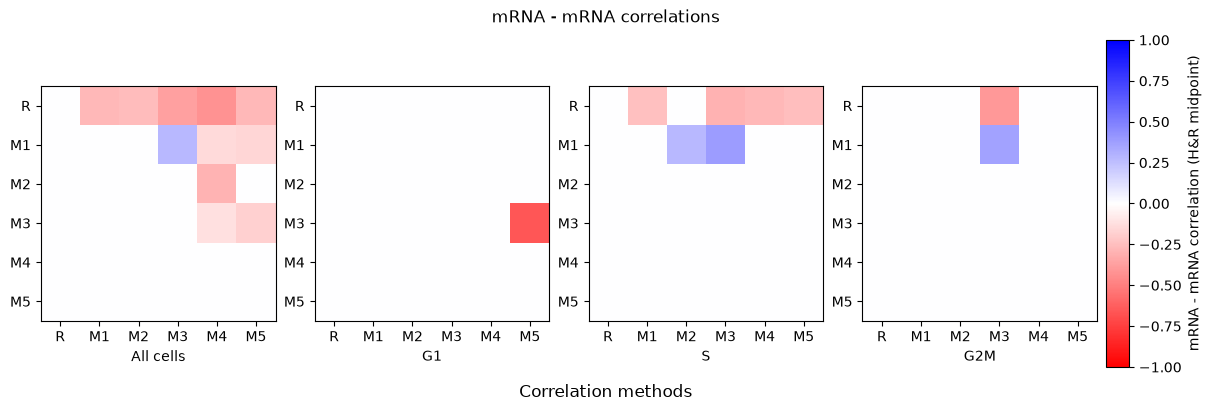

In [22]:
cmap = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
fig, axs = plt.subplots(1, 5, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 1, 1, 1, 0.1]}, constrained_layout=True)
im = axs[0].imshow(all_matrix, cmap=cmap, vmin=-1, vmax=1)
im = axs[1].imshow(G1_matrix, cmap=cmap, vmin=-1, vmax=1)
im = axs[2].imshow(S_matrix, cmap=cmap, vmin=-1, vmax=1)
im = axs[3].imshow(G2M_matrix, cmap=cmap, vmin=-1, vmax=1)
axs[0].set_xlabel("All cells")
axs[1].set_xlabel("G1")
axs[2].set_xlabel("S")
axs[3].set_xlabel("G2M")
RNA_labels = ["R"] + [f"M{i + 1}" for i in range(T - 1)]
for i in range(4):
    axs[i].set_xticks(range(T))
    axs[i].set_xticklabels(RNA_labels)
    axs[i].set_yticks(range(T))
    axs[i].set_yticklabels(RNA_labels)
fig.supxlabel("Correlation methods")
fig.suptitle("mRNA - mRNA correlations")
plt.colorbar(im, cax=axs[4], label="mRNA - mRNA correlation (H&R midpoint)")
plt.show()

# Pipeline

In [102]:
def cell_cycle_inference_pipeline(miRNA, mRNA):

    # number of RNA
    T = len(mRNA) + 1
    
    # subset adata
    adata_mRNA_chosen = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(mRNA)]
    adata_miRNA_chosen = adata_miRNA[:, adata_miRNA.var['GeneName'] == miRNA]

    # combine 
    adata_chosen = ad.concat([adata_miRNA_chosen, adata_mRNA_chosen], axis=1)

    # split cells by phase
    adata_chosen_G1 = adata_chosen[adata_cc.obs['phase'] == "G1", :]
    adata_chosen_S = adata_chosen[adata_cc.obs['phase'] == "S", :]
    adata_chosen_G2M = adata_chosen[adata_cc.obs['phase'] == "G2M", :]

    # select all gene pairs: no repeats
    Is, Js = np.triu_indices(T, k=1)
    gene_queries = [
        [[int(i)], [int(j)]] for i, j in zip(Is, Js)
    ]

    # construct dataset
    SDP_data = SDP_miRNA.dataset.Dataset()
    SDP_data_G1 = SDP_miRNA.dataset.Dataset()
    SDP_data_S = SDP_miRNA.dataset.Dataset()
    SDP_data_G2M = SDP_miRNA.dataset.Dataset()
    SDP_data.construct_dataset_adata(adata_chosen, adata_chosen, beta, gene_queries)
    SDP_data_G1.construct_dataset_adata(adata_chosen_G1, adata_chosen_G1, beta_G1, gene_queries)
    SDP_data_S.construct_dataset_adata(adata_chosen_S, adata_chosen_S, beta_S, gene_queries)
    SDP_data_G2M.construct_dataset_adata(adata_chosen_G2M, adata_chosen_G2M, beta_G2M, gene_queries)

    # bootstrap
    SDP_data.bootstrap(d=3)
    SDP_data_G1.bootstrap(d=3)
    SDP_data_S.bootstrap(d=3)
    SDP_data_G2M.bootstrap(d=3)

    # model free independence test
    MF_ind = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data, d=3)
    MF_ind.optimized_construction = True
    MF_ind.analyse_dataset()

    MF_ind_G1 = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data_G1, d=3)
    MF_ind_G1.optimized_construction = True
    MF_ind_G1.analyse_dataset()

    MF_ind_S = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data_S, d=3)
    MF_ind_S.optimized_construction = True
    MF_ind_S.analyse_dataset()

    MF_ind_G2M = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data_G2M, d=3)
    MF_ind_G2M.optimized_construction = True
    MF_ind_G2M.analyse_dataset()

    # extract results
    status = np.array([sol['status'] for sol in MF_ind.result_dict.values()])
    status_G1 = np.array([sol['status'] for sol in MF_ind_G1.result_dict.values()])
    status_S = np.array([sol['status'] for sol in MF_ind_S.result_dict.values()])
    status_G2M = np.array([sol['status'] for sol in MF_ind_G2M.result_dict.values()])

    # select indices of interacting pairs
    int_idxs = np.arange(status.size)[status == "INFEASIBLE"]
    int_idxs_G1 = np.arange(status_G1.size)[status_G1 == "INFEASIBLE"]
    int_idxs_S = np.arange(status_S.size)[status_S == "INFEASIBLE"]
    int_idxs_G2M = np.arange(status_G2M.size)[status_G2M == "INFEASIBLE"]
    
    # reduce gene queries to these
    gene_queries = [query for i, query in enumerate(SDP_data.gene_queries) if i in int_idxs]
    gene_queries_G1 = [query for i, query in enumerate(SDP_data_G1.gene_queries) if i in int_idxs_G1]
    gene_queries_S = [query for i, query in enumerate(SDP_data_S.gene_queries) if i in int_idxs_S]
    gene_queries_G2M = [query for i, query in enumerate(SDP_data_G2M.gene_queries) if i in int_idxs_G2M]

    # reduce dataset to interacting pairs
    SDP_data.gene_queries = gene_queries
    SDP_data.total_gene_queries = len(gene_queries)
    SDP_data.moment_bounds = SDP_data.moment_bounds[:, int_idxs, :]

    SDP_data_G1.gene_queries = gene_queries_G1
    SDP_data_G1.total_gene_queries = len(gene_queries_G1)
    SDP_data_G1.moment_bounds = SDP_data_G1.moment_bounds[:, int_idxs_G1, :]

    SDP_data_S.gene_queries = gene_queries_S
    SDP_data_S.total_gene_queries = len(gene_queries_S)
    SDP_data_S.moment_bounds = SDP_data_S.moment_bounds[:, int_idxs_S, :]

    SDP_data_G2M.gene_queries = gene_queries_G2M
    SDP_data_G2M.total_gene_queries = len(gene_queries_G2M)
    SDP_data_G2M.moment_bounds = SDP_data_G2M.moment_bounds[:, int_idxs_G2M, :]

    # model free interacting H&R
    MF_int = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data, d=3)
    MF_int.analyse_dataset()

    MF_int_G1 = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data_G1, d=3)
    MF_int_G1.analyse_dataset()

    MF_int_S = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data_S, d=3)
    MF_int_S.analyse_dataset()

    MF_int_G2M = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data_G2M, d=3)
    MF_int_G2M.analyse_dataset()
    
    # H&R correlations
    _, HAR_intervals = MF_int.compute_dataset_correlation()
    HAR_mid = (HAR_intervals[:, 0] + HAR_intervals[:, 1]) / 2

    _, HAR_intervals_G1 = MF_int_G1.compute_dataset_correlation()
    HAR_mid_G1 = (HAR_intervals_G1[:, 0] + HAR_intervals_G1[:, 1]) / 2

    _, HAR_intervals_S = MF_int_S.compute_dataset_correlation()
    HAR_mid_S = (HAR_intervals_S[:, 0] + HAR_intervals_S[:, 1]) / 2

    _, HAR_intervals_G2M = MF_int_G2M.compute_dataset_correlation()
    HAR_mid_G2M = (HAR_intervals_G2M[:, 0] + HAR_intervals_G2M[:, 1]) / 2

    # construct correlation matrix
    all_matrix = np.zeros((T, T)) * np.nan
    G1_matrix = np.zeros((T, T)) * np.nan
    S_matrix = np.zeros((T, T)) * np.nan
    G2M_matrix = np.zeros((T, T)) * np.nan
    for i, query in enumerate(SDP_data.gene_queries):
        all_matrix[query[0][0], query[1][0]] = HAR_mid[i]
    for i, query in enumerate(SDP_data_G1.gene_queries):
        G1_matrix[query[0][0], query[1][0]] = HAR_mid_G1[i]
    for i, query in enumerate(SDP_data_S.gene_queries):
        S_matrix[query[0][0], query[1][0]] = HAR_mid_S[i]
    for i, query in enumerate(SDP_data_G2M.gene_queries):
        G2M_matrix[query[0][0], query[1][0]] = HAR_mid_G2M[i]

    # collect data
    data = {
        'all_matrix': all_matrix,
        'G1_matrix': G1_matrix,
        'S_matrix': S_matrix,
        'G2M_matrix': G2M_matrix,
    }

    return data

In [63]:
def heatmap_plot(data):

    T = data['all_matrix'].shape[0]

    cmap = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
    fig, axs = plt.subplots(1, 5, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 1, 1, 1, 0.1]}, constrained_layout=True)
    im = axs[0].imshow(data['all_matrix'], cmap=cmap, vmin=-1, vmax=1)
    im = axs[1].imshow(data['G1_matrix'], cmap=cmap, vmin=-1, vmax=1)
    im = axs[2].imshow(data['S_matrix'], cmap=cmap, vmin=-1, vmax=1)
    im = axs[3].imshow(data['G2M_matrix'], cmap=cmap, vmin=-1, vmax=1)
    axs[0].set_xlabel("All cells")
    axs[1].set_xlabel("G1")
    axs[2].set_xlabel("S")
    axs[3].set_xlabel("G2M")
    RNA_labels = ["R"] + [f"T{i + 1}" for i in range(T - 1)]
    for i in range(4):
        axs[i].set_xticks(range(T))
        axs[i].set_xticklabels(RNA_labels)
        axs[i].set_yticks(range(T))
        axs[i].set_yticklabels(RNA_labels)
    fig.supxlabel("Correlation methods")
    fig.suptitle("mRNA - mRNA correlations")
    plt.colorbar(im, cax=axs[4], label="mRNA - mRNA correlation (H&R midpoint)")
    plt.show()

In [94]:
def violin_plot(data):

    fig, axs = plt.subplots(figsize=(12, 6))
    plot_colors = ["blue", "red", "orange", "green"]
    plot_data_list = [
        data['all_matrix'][np.triu_indices_from(data['all_matrix'], k=1)],
        data['G1_matrix'][np.triu_indices_from(data['G1_matrix'], k=1)],
        data['S_matrix'][np.triu_indices_from(data['S_matrix'], k=1)],
        data['G2M_matrix'][np.triu_indices_from(data['G2M_matrix'], k=1)]
    ]
    for i, plot_data in enumerate(plot_data_list):
        vp = axs.violinplot(
            dataset=plot_data,
            positions=[i],
            showextrema=False,
            side="both"
        )
        plt.setp(vp['bodies'], facecolor=plot_colors[i], edgecolor='black')
        plt.scatter([i] * len(plot_data), plot_data, color=plot_colors[i], alpha=0.5, s=10)
    axs.axhline(0, color="grey", alpha=0.5)
    axs.set_xticks([0, 1, 2, 3])
    axs.set_xticklabels(["All cells", "G1", "S", "G2M"])
    axs.set_xlabel("Cell cycle phase")
    axs.set_ylabel("mRNA - mRNA correlation (H&R midpoint)")
    axs.set_title("Effects of cell cycle phase on correlations between mRNA")
    plt.show()

In [95]:
def violin_plot_miRNA(data):

    fig, axs = plt.subplots(figsize=(12, 6))
    plot_colors = ["blue", "red", "orange", "green"]
    plot_data_list = [
        data['all_matrix'][0, 1:],
        data['G1_matrix'][0, 1:],
        data['S_matrix'][0, 1:],
        data['G2M_matrix'][0, 1:]
    ]
    for i, plot_data in enumerate(plot_data_list):
        vp = axs.violinplot(
            dataset=plot_data,
            positions=[i],
            showextrema=False,
            side="both"
        )
        plt.setp(vp['bodies'], facecolor=plot_colors[i], edgecolor='black')
        plt.scatter([i] * len(plot_data), plot_data, color=plot_colors[i], alpha=0.5, s=10)
    axs.axhline(0, color="grey", alpha=0.5)
    axs.set_xticks([0, 1, 2, 3])
    axs.set_xticklabels(["All cells", "G1", "S", "G2M"])
    axs.set_xlabel("Cell cycle phase")
    axs.set_ylabel("miRNA - mRNA correlation (H&R midpoint)")
    axs.set_title("Effects of cell cycle phase on correlations of miRNA with target mRNA")
    plt.show()

In [96]:
def violin_plot_mRNA(data):

    fig, axs = plt.subplots(figsize=(12, 6))
    plot_colors = ["blue", "red", "orange", "green"]
    T = data['all_matrix'].shape[0]
    plot_data_list = [
        data['all_matrix'][1:, 1:][np.triu_indices(T - 1, k=1)],
        data['G1_matrix'][1:, 1:][np.triu_indices(T - 1, k=1)],
        data['S_matrix'][1:, 1:][np.triu_indices(T - 1, k=1)],
        data['G2M_matrix'][1:, 1:][np.triu_indices(T - 1, k=1)]
    ]
    for i, plot_data in enumerate(plot_data_list):
        vp = axs.violinplot(
            dataset=plot_data,
            positions=[i],
            showextrema=False,
            side="both"
        )
        plt.setp(vp['bodies'], facecolor=plot_colors[i], edgecolor='black')
        plt.scatter([i] * len(plot_data), plot_data, color=plot_colors[i], alpha=0.5, s=10)
    axs.axhline(0, color="grey", alpha=0.5)
    axs.set_xticks([0, 1, 2, 3])
    axs.set_xticklabels(["All cells", "G1", "S", "G2M"])
    axs.set_xlabel("Cell cycle phase")
    axs.set_ylabel("mRNA - mRNA correlation (H&R midpoint)")
    axs.set_title("Effects of cell cycle phase on correlations between mRNA")
    plt.show()

## Test

In [103]:
# choose miRNA
miRNA = "MIR4709"

# choose mRNA: negatively correlated using all cells
mRNA = np.array(['LRBA', 'PWWP2A', 'IMMP2L', 'WDR76', 'ZNF557'])

# run
data_test = cell_cycle_inference_pipeline(miRNA, mRNA)

100%|██████████| 11/11 [00:05<00:00,  2.10it/s]
0it [00:00, ?it/s]
100%|██████████| 11/11 [00:00<00:00, 60.17it/s]
0it [00:00, ?it/s]
100%|██████████| 2/2 [00:00<00:00, 48.37it/s]


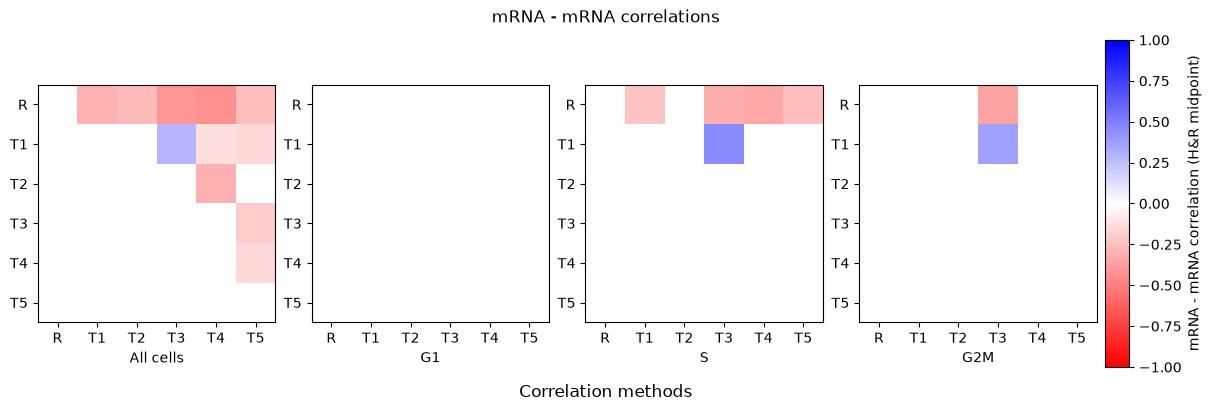

In [104]:
# plot
heatmap_plot(data_test)

## Negative correlation

In [107]:
# size
M = 25

# choose miRNA
miRNA = "MIR4709"

# select results
ind = ind_MF_df[f'{miRNA}_status']
mid = int_MF_df[f'{miRNA}_HAR_mid']

# get names of negatively correlated interacting pcRNA
mRNA = mid[mid < -0.25].index.tolist()
mRNA = rng.choice(mRNA, size=M, replace=False)

# run
data_neg = cell_cycle_inference_pipeline(miRNA, mRNA)

100%|██████████| 67/67 [00:00<00:00, 74.18it/s]


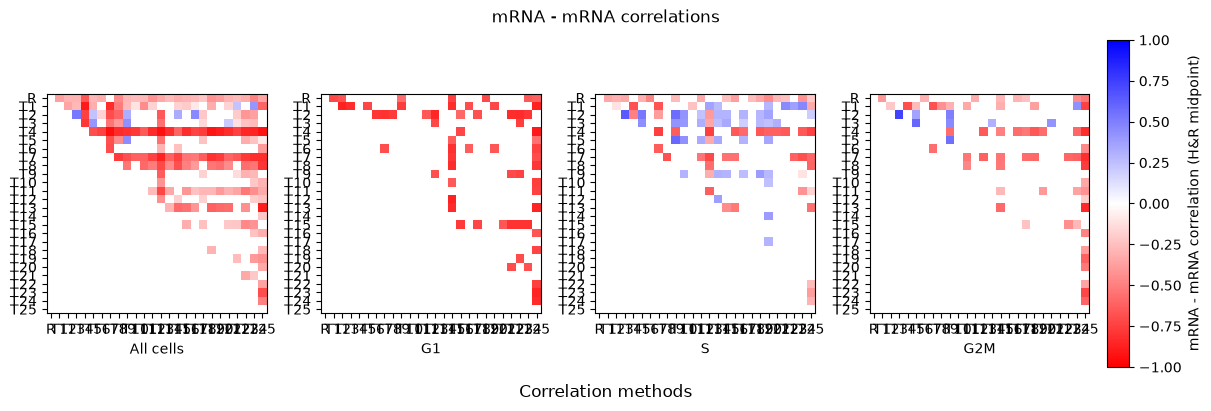

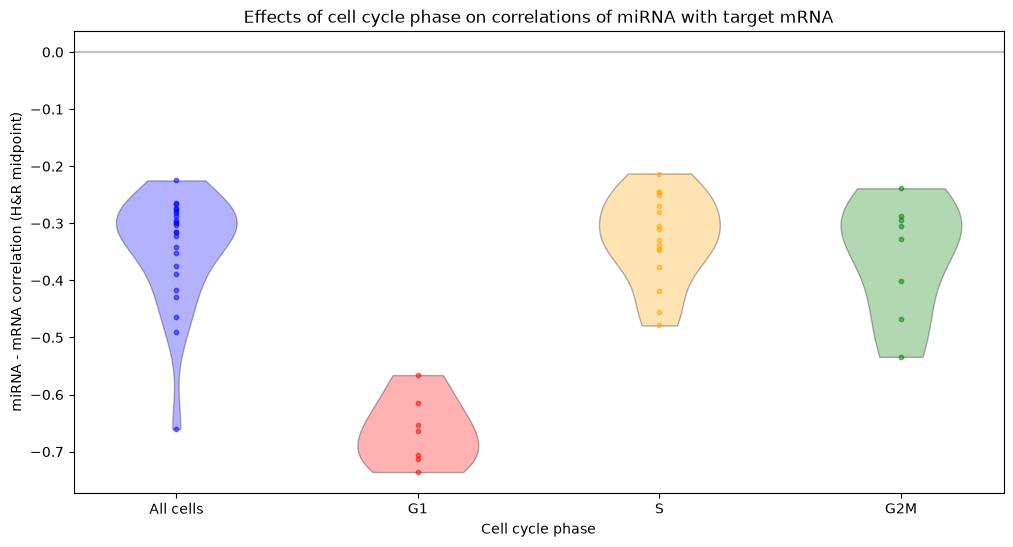

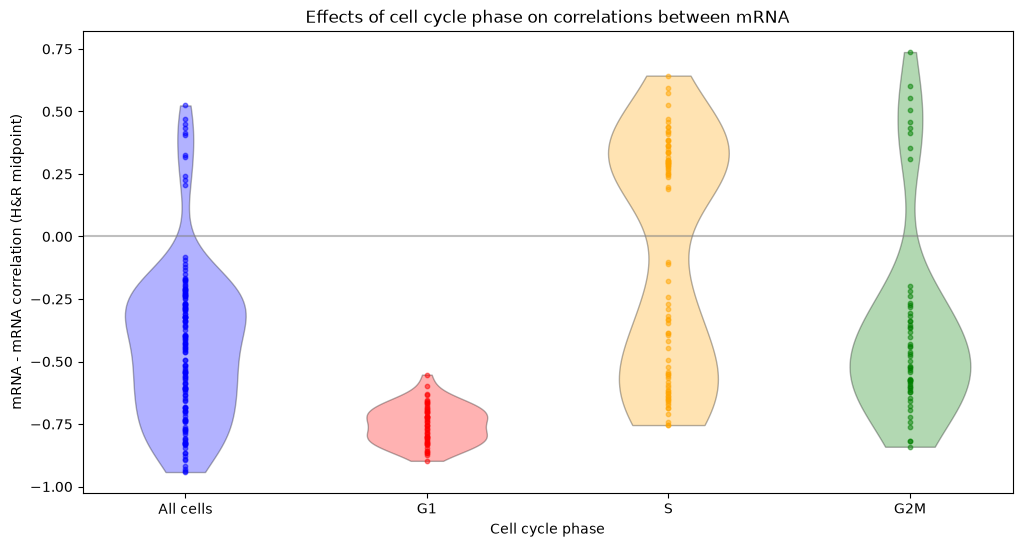

In [108]:
heatmap_plot(data_neg)
violin_plot_miRNA(data_neg)
violin_plot_mRNA(data_neg)

## Positive correlation

In [109]:
# size
M = 25

# choose miRNA
miRNA = "MIR4709"

# select results
ind = ind_MF_df[f'{miRNA}_status']
mid = int_MF_df[f'{miRNA}_HAR_mid']

# get names of positively correlated interacting pcRNA
mRNA = mid[mid > 0.25].index.tolist()
mRNA = rng.choice(mRNA, size=M, replace=False)

# run
data_pos = cell_cycle_inference_pipeline(miRNA, mRNA)

100%|██████████| 279/279 [02:09<00:00,  2.16it/s]
0it [00:00, ?it/s]
100%|██████████| 279/279 [00:03<00:00, 78.27it/s]
0it [00:00, ?it/s]
100%|██████████| 32/32 [00:00<00:00, 68.54it/s]


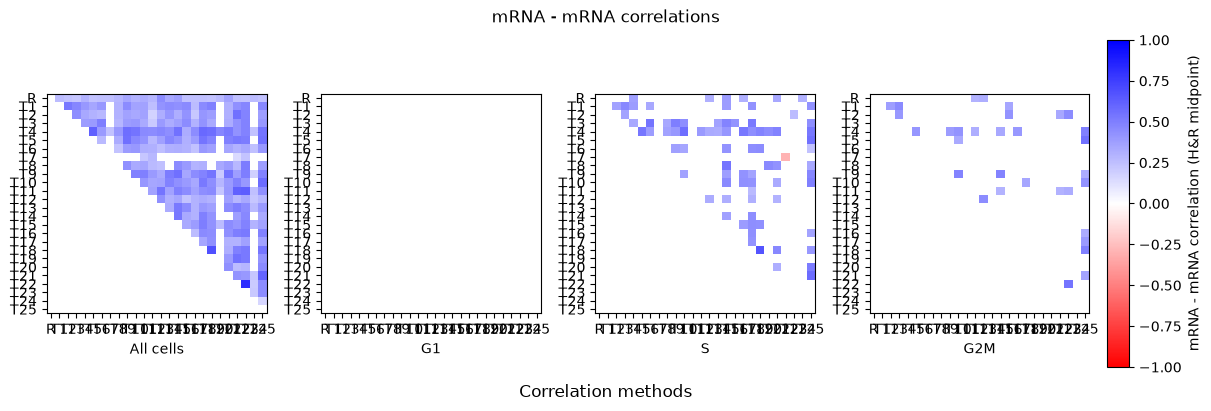

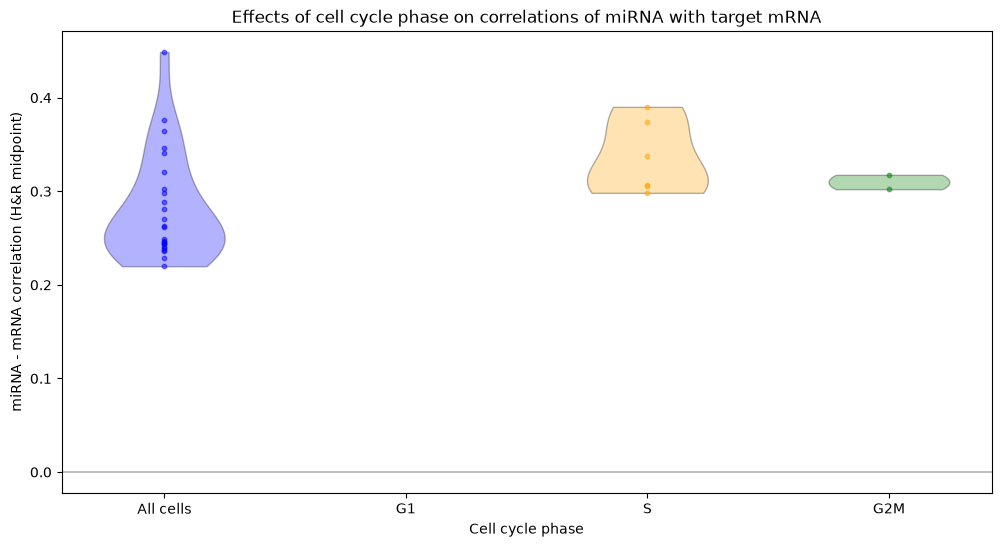

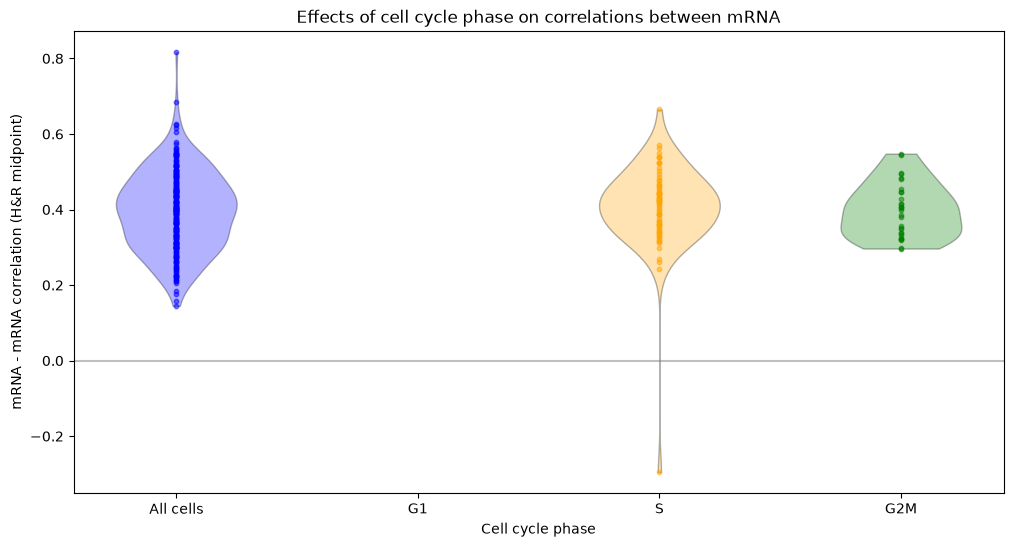

In [110]:
heatmap_plot(data_pos)
violin_plot_miRNA(data_pos)
violin_plot_mRNA(data_pos)

## Independent

In [111]:
# size
M = 25

# choose miRNA
miRNA = "MIR4709"

# select results
ind = ind_MF_df[f'{miRNA}_status']
mid = int_MF_df[f'{miRNA}_HAR_mid']

# get names of independent pcRNA
mask_ind = (ind == "OPTIMAL")
mRNA = mask_ind.index[mask_ind.values.squeeze()].tolist()
mRNA = rng.choice(mRNA, size=M, replace=False)

# run
data_ind = cell_cycle_inference_pipeline(miRNA, mRNA)

100%|██████████| 20/20 [00:00<00:00, 68.72it/s]


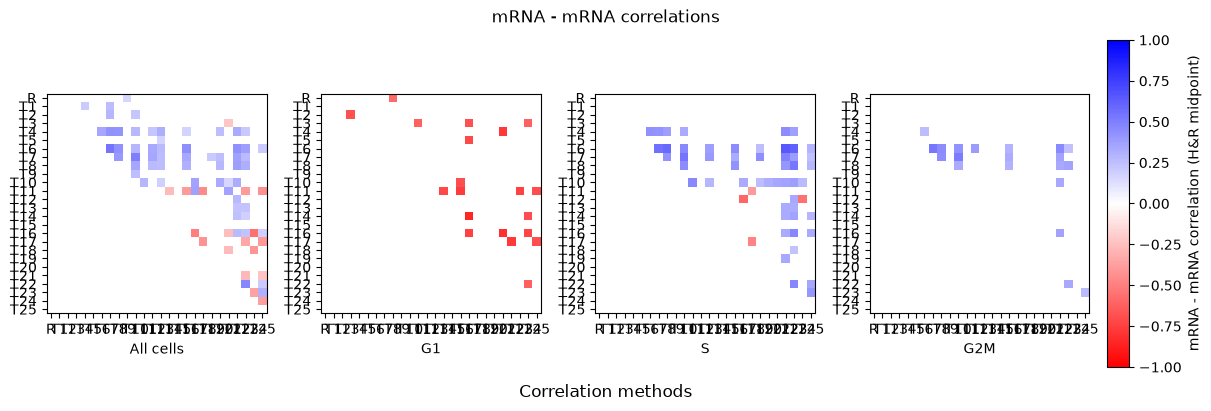

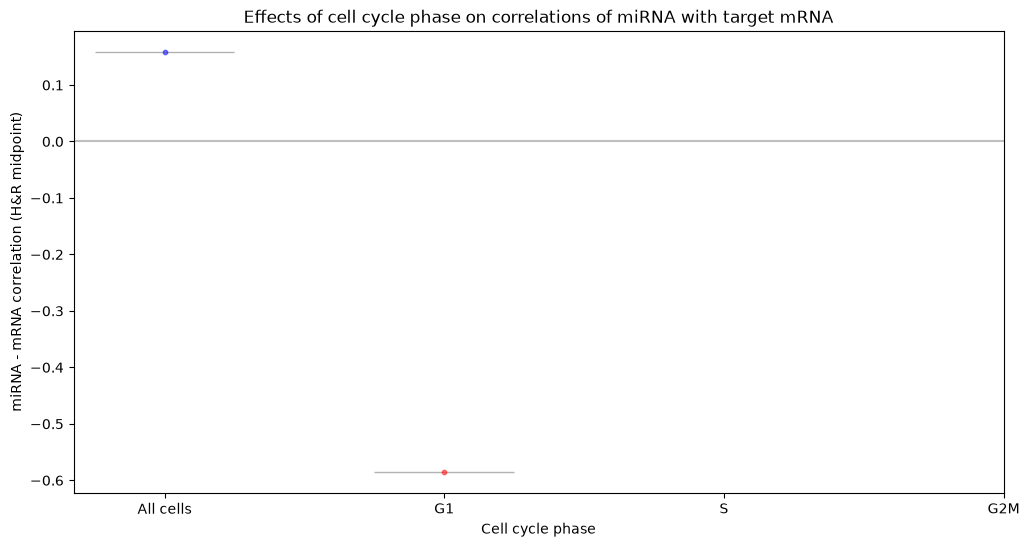

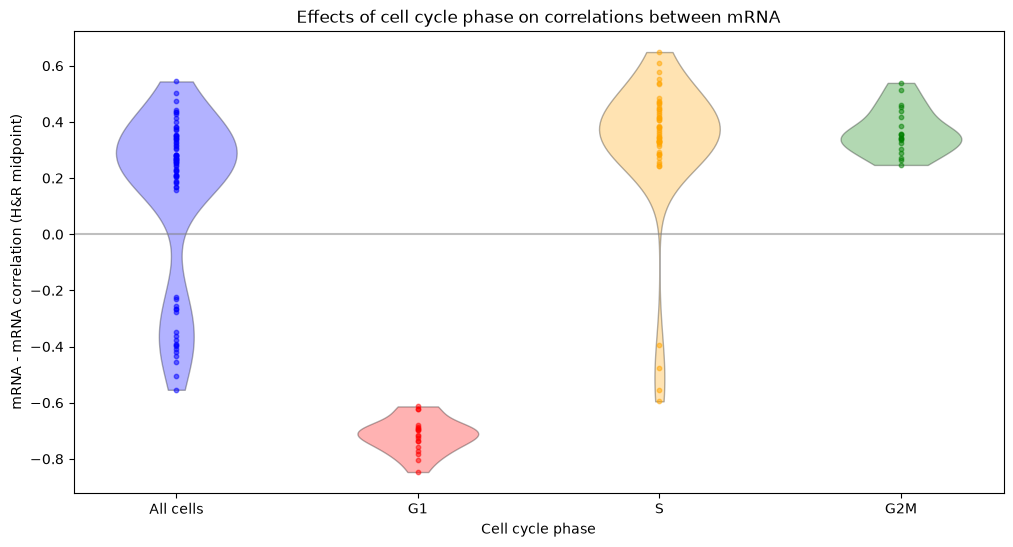

In [112]:
heatmap_plot(data_ind)
violin_plot_miRNA(data_ind)
violin_plot_mRNA(data_ind)

# Consistency across miRNA

Choose some random miRNAs and repeat runs to see if consistent behaviour or if e.g. some are constant over cell cycle, while others vary sig.

In [115]:
print(adata_miRNA.var['GeneName'].values.tolist())

['ENSG00000278791', 'MIR3917', 'MIR5087', 'MIR4258', 'MIR3658', 'MIR4426', 'MIR4444-1', 'MIR7845', 'MIR1244-1', 'MIR5001', 'MIR4442', 'MIR564', 'MIR3655', 'MIR4647', 'MIR3654', 'MIR320A', 'MIR7705', 'MIR3610', 'ENSG00000221184', 'MIR2110', 'MIR6125', 'MIR3652', 'MIR8072', 'MIR17', 'MIR4709', 'MIR147B', 'MIR7706', 'MIR3178', 'MIR484', 'MIR4519', 'MIR4521', 'MIR632', 'MIR3615', 'MIR4741', 'MIR1181', 'MIR639', 'MIR4751', 'MIR6805', 'MIR663A', 'MIR6821', 'MIR222']


## MIR3658

In [ ]:
# size
M = 25

# choose miRNA
miRNA = "MIR3658"

# select results
ind = ind_MF_df[f'{miRNA}_status']
mid = int_MF_df[f'{miRNA}_HAR_mid']

# get names of negatively correlated interacting pcRNA
mRNA_neg = mid[mid < -0.25].index.tolist()
mRNA_neg = rng.choice(mRNA_neg, size=M, replace=False)

# get names of positively correlated interacting pcRNA
mRNA_pos = mid[mid > 0.25].index.tolist()
mRNA_pos = rng.choice(mRNA_pos, size=M, replace=False)

# get names of independent pcRNA
mask_ind = (ind == "OPTIMAL")
mRNA_ind = mask_ind.index[mask_ind.values.squeeze()].tolist()
mRNA_ind = rng.choice(mRNA_ind, size=M, replace=False)

# run
data_neg = cell_cycle_inference_pipeline(miRNA, mRNA_neg)
data_pos = cell_cycle_inference_pipeline(miRNA, mRNA_pos)
data_ind = cell_cycle_inference_pipeline(miRNA, mRNA_ind)

 69%|██████▉   | 133/193 [01:01<00:26,  2.29it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_312_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 73%|███████▎  | 141/193 [01:05<00:23,  2.17it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_312_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 99%|█████████▉| 192/193 [01:27<00:00,  2.24it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_312_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range
100%|██████████| 193/193 [01:27<00:00,  2.21it/s]


...

 97%|█████████▋| 188/193 [00:02<00:00, 75.64it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_312_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 403, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
100%|██████████| 193/193 [00:02<00:00, 71.48it/s]


Computation failed: 'NoneType' object is not iterable


 96%|█████████▌| 85/89 [00:01<00:00, 86.27it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_312_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 403, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
100%|██████████| 89/89 [00:01<00:00, 80.58it/s]


Computation failed: 'NoneType' object is not iterable


100%|██████████| 284/284 [02:08<00:00,  2.20it/s]
0it [00:00, ?it/s]
100%|██████████| 284/284 [00:04<00:00, 70.03it/s]
0it [00:00, ?it/s]
100%|██████████| 4/4 [00:00<00:00, 121.37it/s]


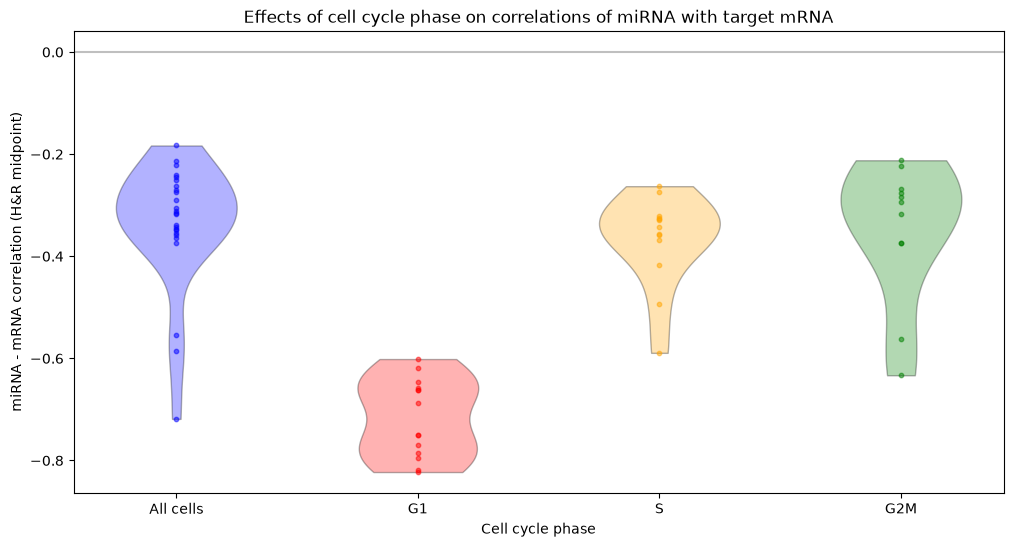

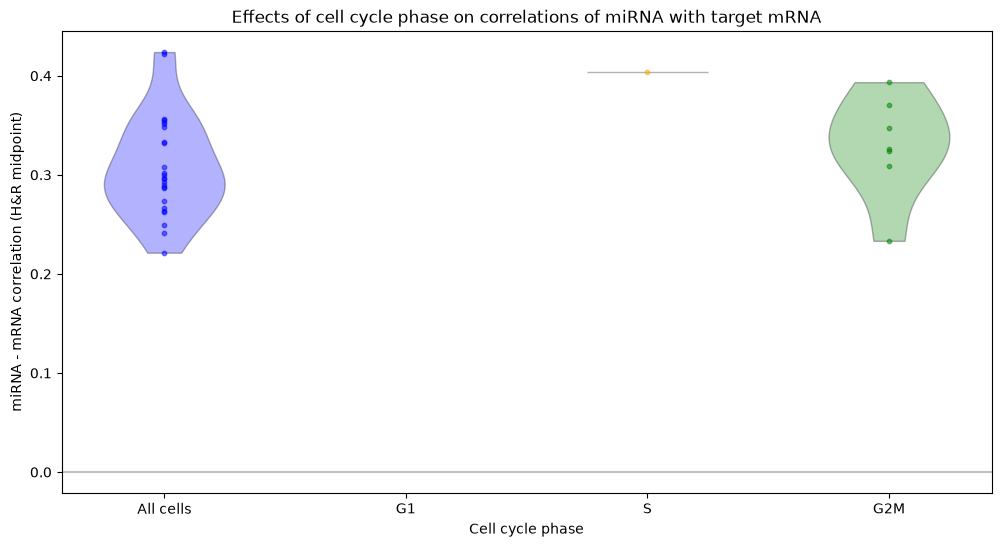

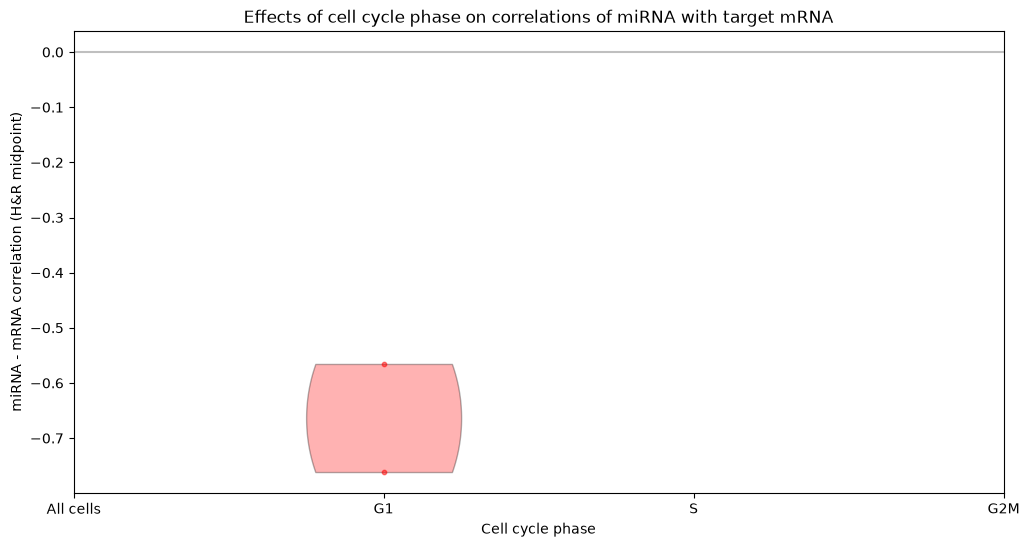

In [120]:
violin_plot_miRNA(data_neg)
violin_plot_miRNA(data_pos)
violin_plot_miRNA(data_ind)

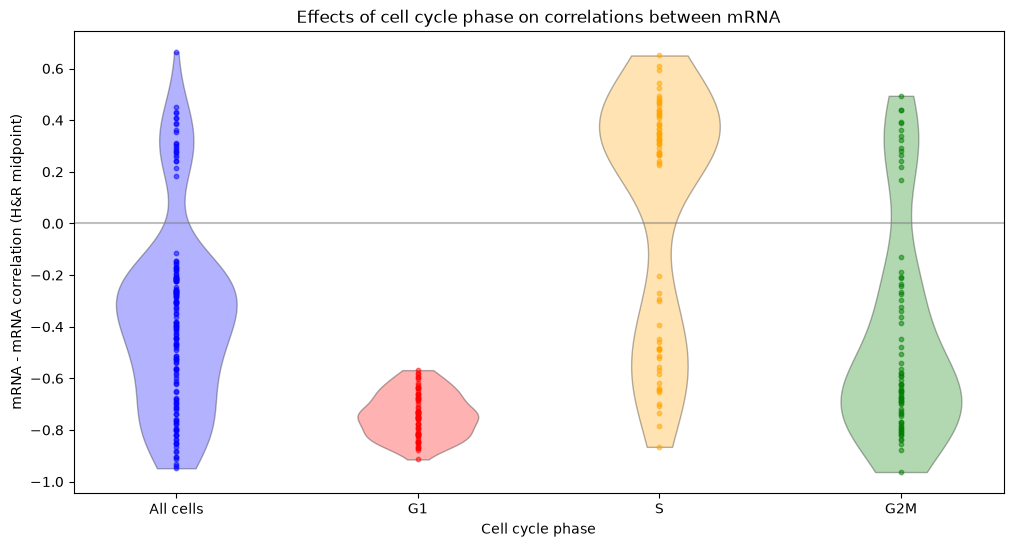

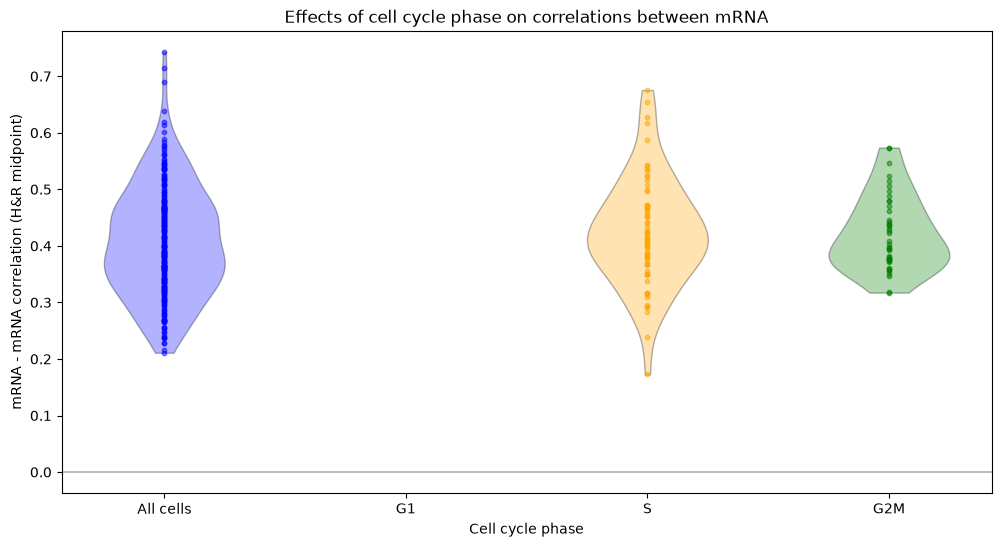

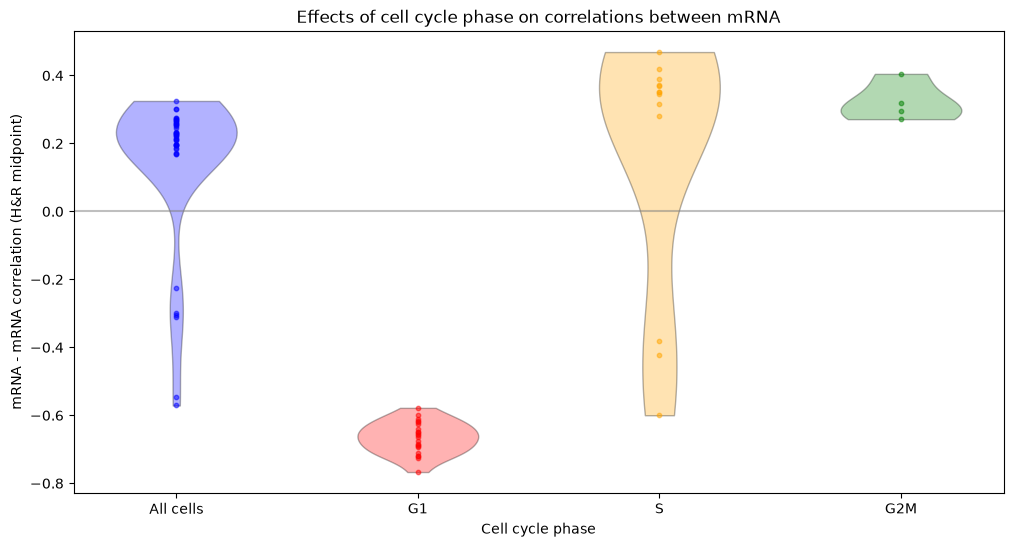

In [121]:
violin_plot_mRNA(data_neg)
violin_plot_mRNA(data_pos)
violin_plot_mRNA(data_ind)

## MIR663A

In [122]:
# size
M = 25

# choose miRNA
miRNA = "MIR663A"

# select results
ind = ind_MF_df[f'{miRNA}_status']
mid = int_MF_df[f'{miRNA}_HAR_mid']

# get names of negatively correlated interacting pcRNA
mRNA_neg = mid[mid < -0.25].index.tolist()
mRNA_neg = rng.choice(mRNA_neg, size=M, replace=False)

# get names of positively correlated interacting pcRNA
mRNA_pos = mid[mid > 0.25].index.tolist()
mRNA_pos = rng.choice(mRNA_pos, size=M, replace=False)

# get names of independent pcRNA
mask_ind = (ind == "OPTIMAL")
mRNA_ind = mask_ind.index[mask_ind.values.squeeze()].tolist()
mRNA_ind = rng.choice(mRNA_ind, size=M, replace=False)

# run
data_neg = cell_cycle_inference_pipeline(miRNA, mRNA_neg)
data_pos = cell_cycle_inference_pipeline(miRNA, mRNA_pos)
data_ind = cell_cycle_inference_pipeline(miRNA, mRNA_ind)

100%|██████████| 7/7 [00:00<00:00, 62.43it/s]


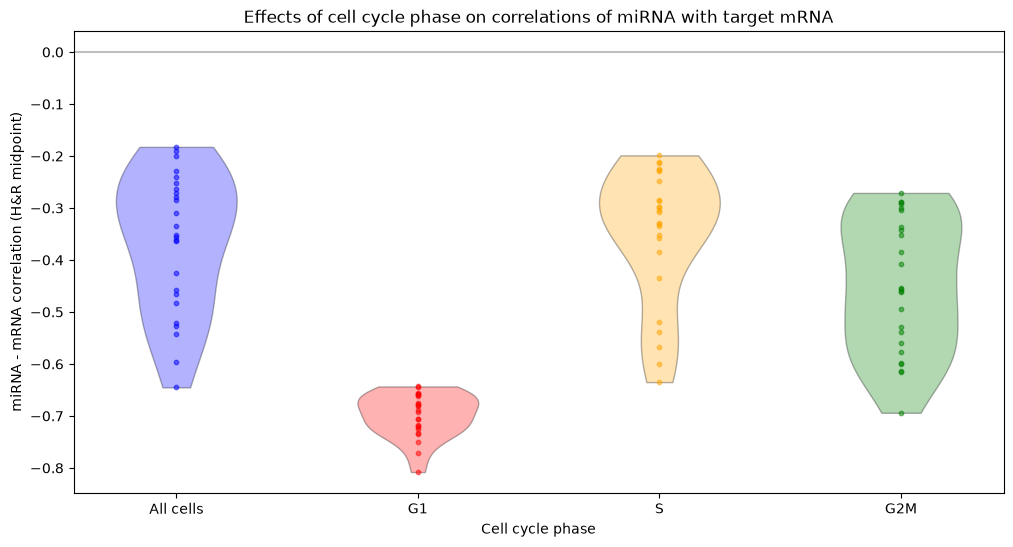

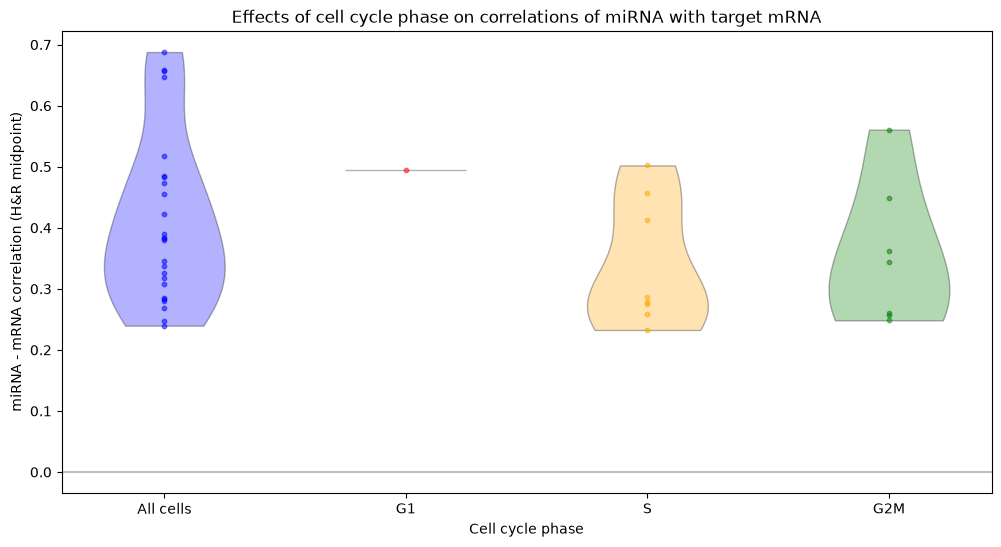

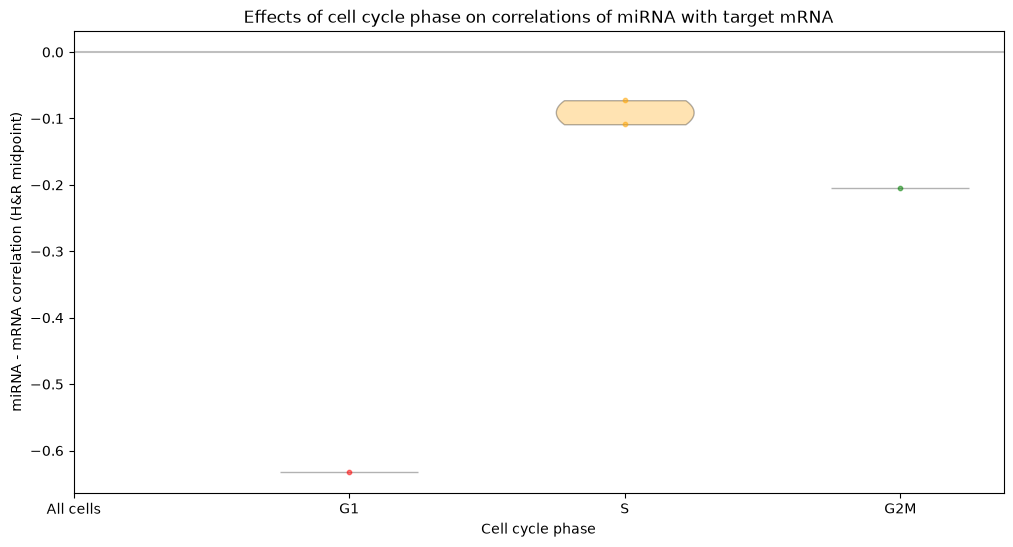

In [123]:
violin_plot_miRNA(data_neg)
violin_plot_miRNA(data_pos)
violin_plot_miRNA(data_ind)

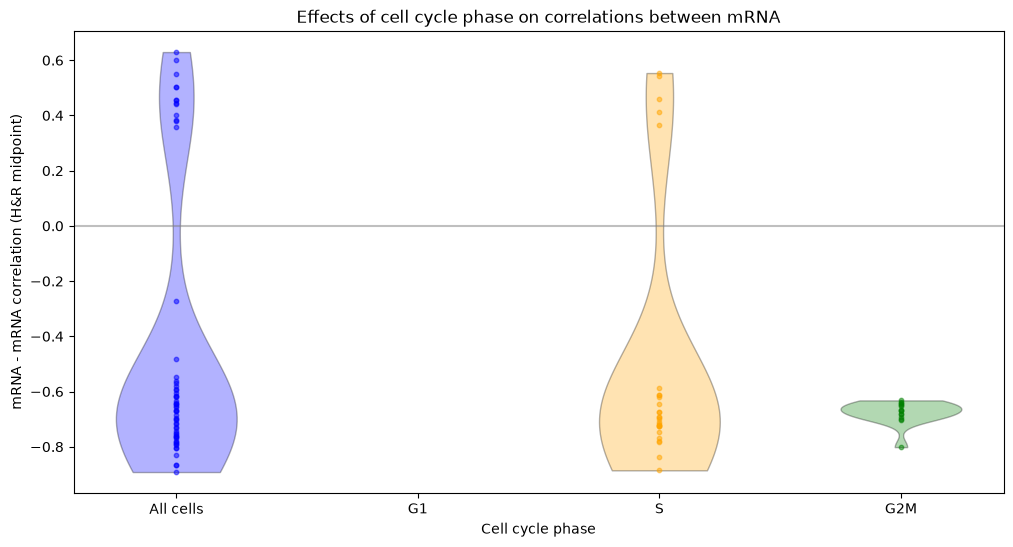

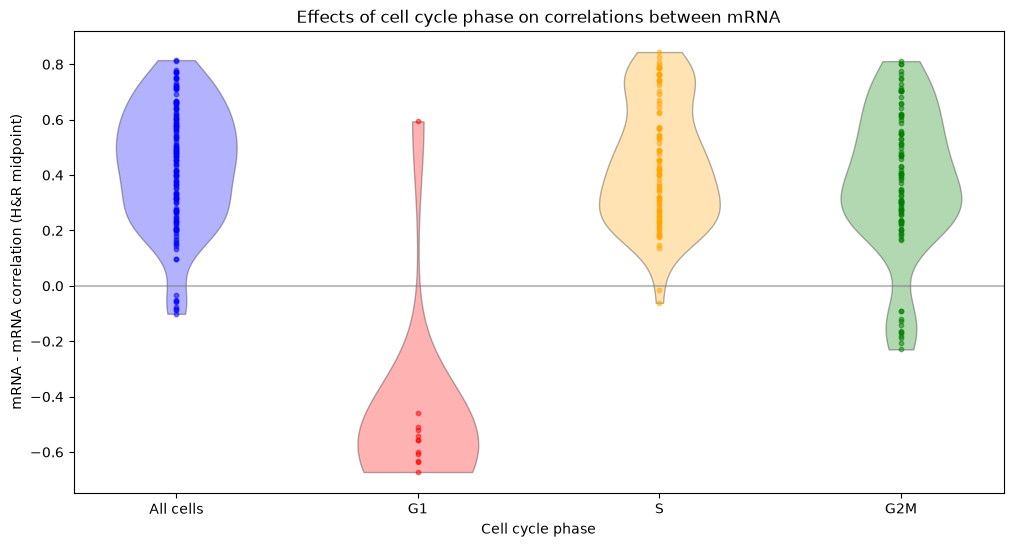

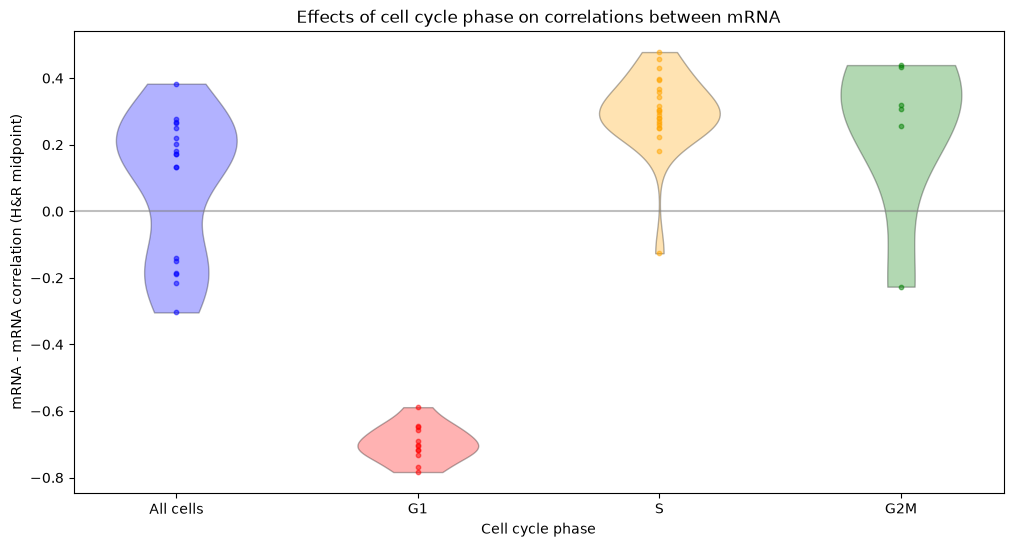

In [124]:
violin_plot_mRNA(data_neg)
violin_plot_mRNA(data_pos)
violin_plot_mRNA(data_ind)

## MIR6823

- no positive correlations

In [125]:
# size
M = 25

# choose miRNA
miRNA = "MIR663A"

# select results
ind = ind_MF_df[f'{miRNA}_status']
mid = int_MF_df[f'{miRNA}_HAR_mid']

# get names of negatively correlated interacting pcRNA
mRNA_neg = mid[mid < -0.25].index.tolist()
mRNA_neg = rng.choice(mRNA_neg, size=M, replace=False)

# get names of independent pcRNA
mask_ind = (ind == "OPTIMAL")
mRNA_ind = mask_ind.index[mask_ind.values.squeeze()].tolist()
mRNA_ind = rng.choice(mRNA_ind, size=M, replace=False)

# run
data_neg = cell_cycle_inference_pipeline(miRNA, mRNA_neg)
data_ind = cell_cycle_inference_pipeline(miRNA, mRNA_ind)

 39%|███▊      | 53/137 [00:22<00:37,  2.24it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_312_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 58%|█████▊    | 80/137 [00:34<00:24,  2.29it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_312_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 60%|█████▉    | 82/137 [00:35<00:18,  2.92it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_312_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range
Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_312_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

 56%|█████▌    | 56/100 [00:00<00:00, 87.03it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_312_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 403, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 74%|███████▍  | 74/100 [00:00<00:00, 83.90it/s]

Computation failed: 'NoneType' object is not iterable


 57%|█████▋    | 48/84 [00:00<00:00, 90.74it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_312_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 403, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 70%|███████   | 59/84 [00:00<00:00, 94.71it/s]

Computation failed: 'NoneType' object is not iterable


100%|██████████| 13/13 [00:00<00:00, 72.75it/s]


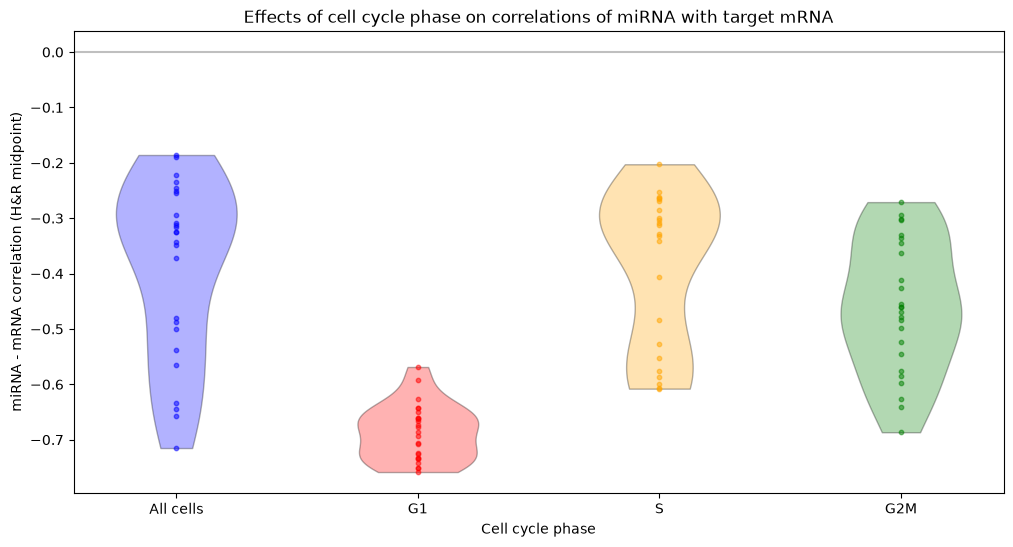

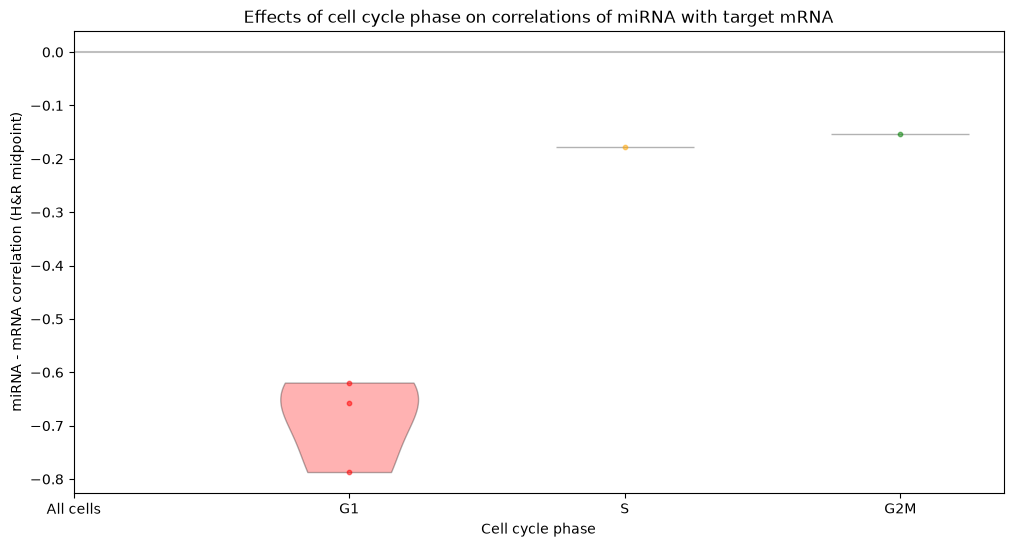

In [126]:
violin_plot_miRNA(data_neg)
violin_plot_miRNA(data_ind)

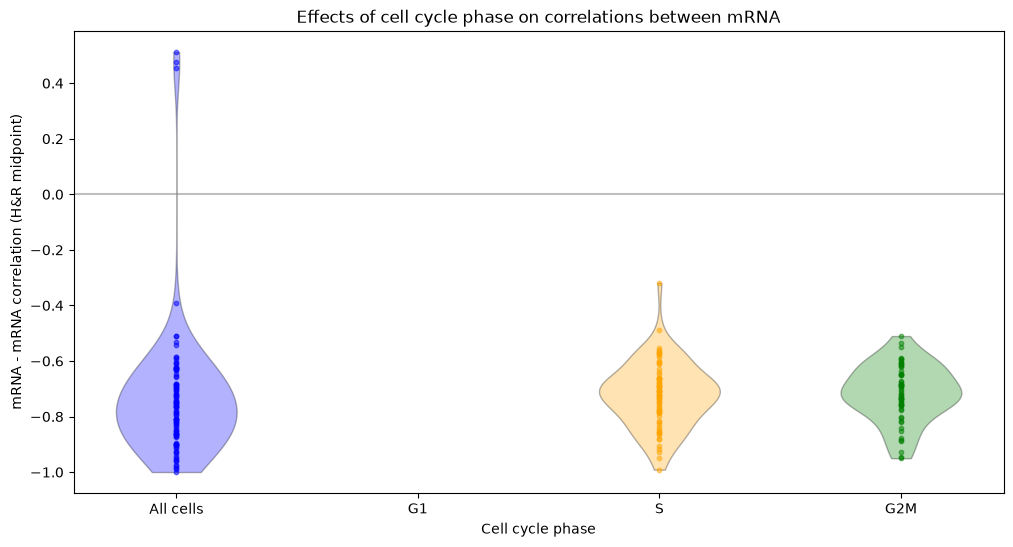

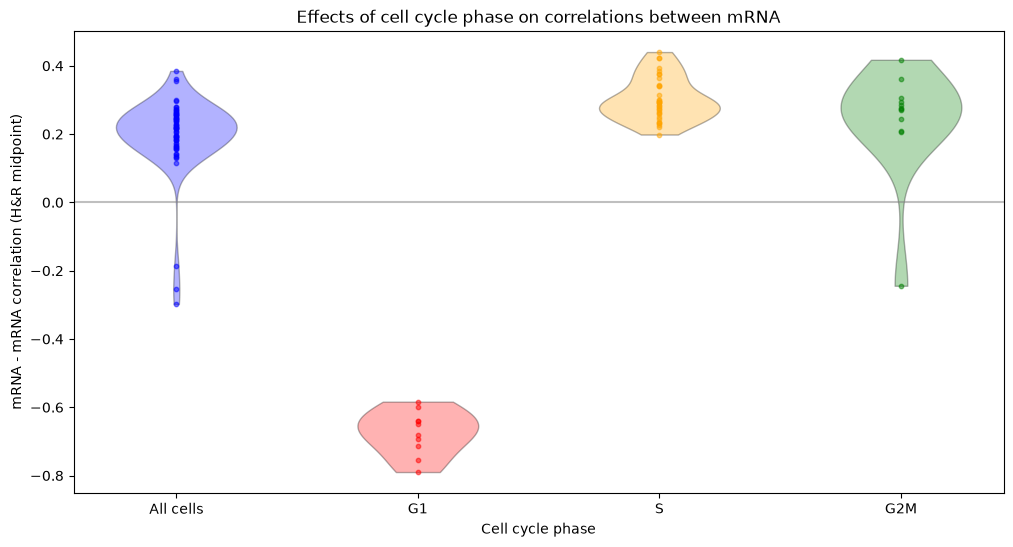

In [127]:
violin_plot_mRNA(data_neg)
violin_plot_mRNA(data_ind)

# Appendix

In [ ]:
# choose miRNA
miRNA = "MIR4709"

# choose mRNA: negatively correlated using all cells
mRNA = np.array(['MIR4709', 'LRBA', 'PWWP2A', 'IMMP2L', 'WDR76', 'ZNF557'])

# run
data_test = cell_cycle_inference_pipeline(miRNA, mRNA, plot_heatmap=True, plot_violin=True)

In [ ]:
# size
M = 25

# get names of negatively correlated interacting pcRNA
names_neg = mid[mid < -0.25].index.tolist()
names_neg = rng.choice(names_neg, size=M, replace=False)

# get names of positively correlated interacting pcRNA
names_pos = mid[mid > 0.25].index.tolist()
names_pos = rng.choice(names_pos, size=M, replace=False)

# get names of independent pcRNA
mask_ind = (ind == "OPTIMAL")
names_ind = mask_ind.index[mask_ind.values.squeeze()].tolist()
names_ind = rng.choice(names_ind, size=M, replace=False)

# subset adata
adata_neg = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_neg)]
adata_pos = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_pos)]
adata_ind = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_ind)]

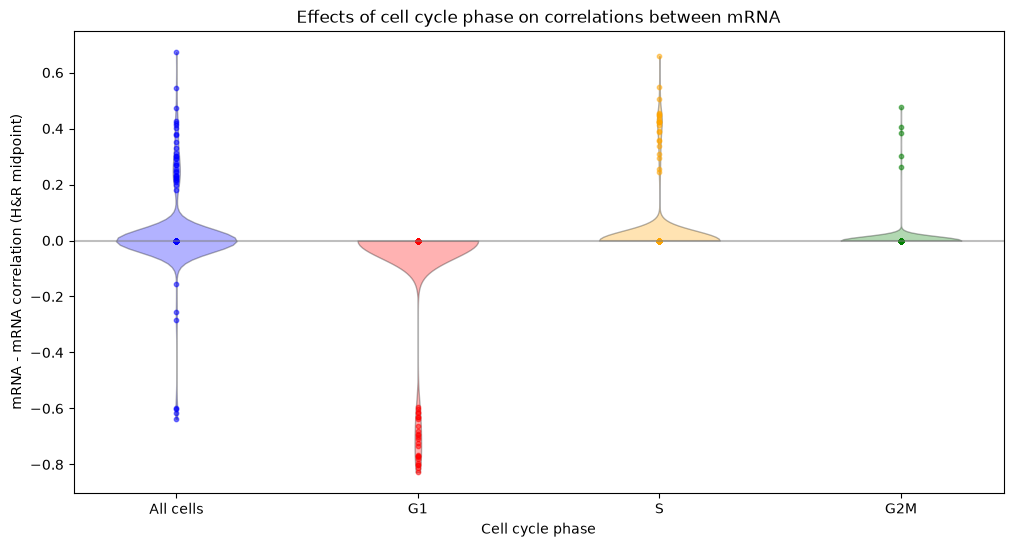

In [100]:
data = data_ind

fig, axs = plt.subplots(figsize=(12, 6))
plot_colors = ["blue", "red", "orange", "green"]
T = data['all_matrix'].shape[0]
plot_data_list = [
    data['all_matrix'][1:, 1:][np.triu_indices(T - 1, k=1)],
    data['G1_matrix'][1:, 1:][np.triu_indices(T - 1, k=1)],
    data['S_matrix'][1:, 1:][np.triu_indices(T - 1, k=1)],
    data['G2M_matrix'][1:, 1:][np.triu_indices(T - 1, k=1)]
]
for i, plot_data in enumerate(plot_data_list):
    vp = axs.violinplot(
        dataset=plot_data,
        positions=[i],
        showextrema=False,
        side="both"
    )
    plt.setp(vp['bodies'], facecolor=plot_colors[i], edgecolor='black')
    plt.scatter([i] * len(plot_data), plot_data, color=plot_colors[i], alpha=0.5, s=10)
axs.axhline(0, color="grey", alpha=0.5)
axs.set_xticks([0, 1, 2, 3])
axs.set_xticklabels(["All cells", "G1", "S", "G2M"])
axs.set_xlabel("Cell cycle phase")
axs.set_ylabel("mRNA - mRNA correlation (H&R midpoint)")
axs.set_title("Effects of cell cycle phase on correlations between mRNA")
plt.show()

In [101]:
plot_data

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     